<a href="https://colab.research.google.com/github/praba-engineer/Intelligent-Data-Modelling-with-Python/blob/main/Capstone_Prabakaran.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone Project: Building a Multimodal AI Application with Python

**Author:** Prabakaran

**Goal:** Idha oru end-to-end multimodal AI application — image-ah pathu caption generate pannurathu, andha image-ah kaettu kelvi kekurathu (Visual Question Answering), image-ah text labels-oda match pannurathu (zero-shot classification), matrum andha caption-a vachi oru chinna creative story generate pannurathu.

**Modalities used:** Image + Text

**Models used (all free, HuggingFace Transformers):**
- `Salesforce/blip-image-captioning-base` — Image Captioning
- `Salesforce/blip-vqa-base` — Visual Question Answering
- `openai/clip-vit-base-patch32` — Zero-shot Image Classification
- `gpt2` — Text generation (caption -> short story)

> This notebook is designed to run directly on **Google Colab**. Just open it in Colab and run cells top to bottom. GPU runtime (Runtime > Change runtime type > GPU) is recommended but not mandatory.

## 1. Setup — Install Required Libraries

In [ ]:
!pip install -q transformers torch torchvision pillow requests accelerate

## 2. Import Libraries

In [ ]:
import torch
from PIL import Image
import requests
from io import BytesIO
import matplotlib.pyplot as plt

from transformers import (
    BlipProcessor, BlipForConditionalGeneration,
    BlipForQuestionAnswering,
    CLIPProcessor, CLIPModel,
    pipeline
)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

Using device: cpu


## 3. Helper Function — Load Image from URL or Upload

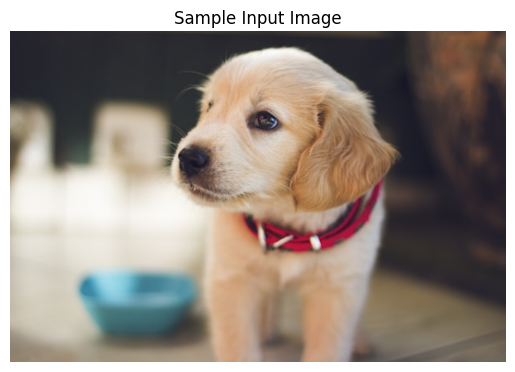

In [ ]:
def load_image_from_url(url):
    response = requests.get(url)
    img = Image.open(BytesIO(response.content)).convert("RGB")
    return img

def show_image(img, title="Image"):
    plt.imshow(img)
    plt.axis("off")
    plt.title(title)
    plt.show()

# Sample image (free to use, from Unsplash)
sample_url = "https://images.unsplash.com/photo-1507146426996-ef05306b995a?w=600"
image = load_image_from_url(sample_url)
show_image(image, "Sample Input Image")

> **Note:** Nee un sொந்த image-ah use pannanum na, Colab left panel la File icon click pannitu image upload pannunga, apparam:
> ```python
> image = Image.open("/content/your_image.jpg").convert("RGB")
> ```

## 4. Module 1 — Image Captioning (BLIP)

In [5]:
caption_processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
caption_model = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-base").to(device)

def generate_caption(img):
    inputs = caption_processor(img, return_tensors="pt").to(device)
    out = caption_model.generate(**inputs, max_new_tokens=40)
    caption = caption_processor.decode(out[0], skip_special_tokens=True)
    return caption

caption = generate_caption(image)
print("Generated Caption:", caption)

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.56k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/506 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

...

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  990MB            

model.safetensors: downloading bytes:           |  0.00B            

Generated Caption: a small dog standing on a wooden floor


## 5. Module 2 — Visual Question Answering (VQA)

In [6]:
vqa_processor = BlipProcessor.from_pretrained("Salesforce/blip-vqa-base")
vqa_model = BlipForQuestionAnswering.from_pretrained("Salesforce/blip-vqa-base").to(device)

def ask_question(img, question):
    inputs = vqa_processor(img, question, return_tensors="pt").to(device)
    out = vqa_model.generate(**inputs, max_new_tokens=20)
    answer = vqa_processor.decode(out[0], skip_special_tokens=True)
    return answer

questions = [
    "What is in the image?",
    "What is the weather like?",
    "How many main objects are visible?"
]

for q in questions:
    print(f"Q: {q}\nA: {ask_question(image, q)}\n")

preprocessor_config.json:   0%|          | 0.00/445 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.56k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.54GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/788 [00:00<?, ?it/s]

Q: What is in the image?
A: puppy

Q: What is the weather like?
A: sunny

Q: How many main objects are visible?
A: 2



## 6. Module 3 — Zero-Shot Image Classification (CLIP)

In [ ]:
clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

candidate_labels = ["a mountain landscape", "a city street", "a beach", "a forest", "an animal", "a person"]

def zero_shot_classify(img, labels):
    inputs = clip_processor(text=labels, images=img, return_tensors="pt", padding=True).to(device)
    outputs = clip_model(**inputs)
    probs = outputs.logits_per_image.softmax(dim=1).detach().cpu().numpy()[0]
    results = sorted(zip(labels, probs), key=lambda x: -x[1])
    return results

results = zero_shot_classify(image, candidate_labels)
for label, prob in results:
    print(f"{label}: {prob*100:.2f}%")

## 7. Module 4 — Caption-to-Story Generation (Text Generation with GPT-2)

Idhu multimodal pipeline-oda final step — image-la irundhu vandha caption-ah **prompt** ah use pannitu, oru chinna creative story generate pannuvom. Idhu dhaan real multimodal application-oda core idea: **oru modality (image) -> intermediate representation (text caption) -> another modality output (generated story)**.

In [8]:
story_generator = pipeline("text-generation", model="gpt2", device=0 if device == "cuda" else -1)

prompt = f"Write a short creative story based on this scene: {caption}.\nStory:"
story_output = story_generator(prompt, max_new_tokens=80, num_return_sequences=1, do_sample=True, temperature=0.9)

print(story_output[0]["generated_text"])

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  548MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

...

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

[transformers] Passing `generation_config` together with generation-related arguments=({'do_sample', 'num_return_sequences', 'max_new_tokens', 'temperature'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Both `max_new_tokens` (=80) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer GPT2Tokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


Write a short creative story based on this scene: a small dog standing on a wooden floor.
Story:


One day, a dog stands on a wooden floor. As the dog starts to run toward the dog, the dog is taken to another part of the animal to be watched. Another dog, standing on a wooden floor, continues to follow.

Then there is the final scene. A dog walking on a wooden floor. Behind the dog, an old man is busy making an agreement.


## 8. Full Multimodal Pipeline (Combined Function)

Ellame ஒரே function-ku கீழ combine பண்ணி, easy ah reuse pannalam.

Step 1: Generating caption...
Step 2: Answering visual question...
Step 3: Zero-shot classification...


[transformers] Both `max_new_tokens` (=80) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Step 4: Generating short story...


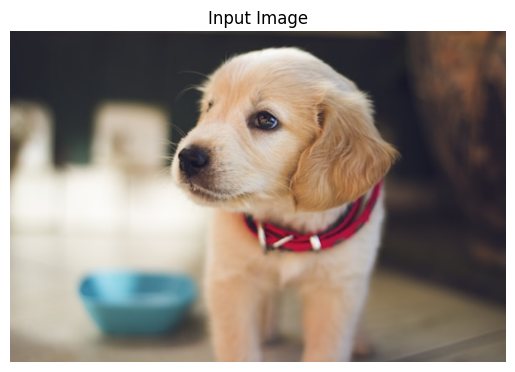


CAPTION:
a small dog standing on a wooden floor

QUESTION:
What is the setting of this image?

ANSWER:
indoors

TOP_CLASS:
an animal

TOP_CLASS_CONFIDENCE:
92.12%

GENERATED_STORY:
Write a short creative story based on this scene: a small dog standing on a wooden floor.
Story:
I have not read the story but I do know that it's about a puppy named Alena who is in a coma after being attacked by a wild wolf. She has to save him but she doesn't seem to care, just that she has to give him a drink or go to bed. (Yes, she has to go to sleep at night. And there are just too many people who


In [9]:
def multimodal_pipeline(img, question="What is happening in the image?", labels=None):
    if labels is None:
        labels = ["a mountain landscape", "a city street", "a beach", "a forest", "an animal", "a person"]

    print("Step 1: Generating caption...")
    cap = generate_caption(img)

    print("Step 2: Answering visual question...")
    ans = ask_question(img, question)

    print("Step 3: Zero-shot classification...")
    cls = zero_shot_classify(img, labels)[0]

    print("Step 4: Generating short story...")
    story_prompt = f"Write a short creative story based on this scene: {cap}.\nStory:"
    story = story_generator(story_prompt, max_new_tokens=80, num_return_sequences=1, do_sample=True, temperature=0.9)[0]["generated_text"]

    return {
        "caption": cap,
        "question": question,
        "answer": ans,
        "top_class": cls[0],
        "top_class_confidence": f"{cls[1]*100:.2f}%",
        "generated_story": story
    }

result = multimodal_pipeline(image, question="What is the setting of this image?")
show_image(image, "Input Image")
for k, v in result.items():
    print(f"\n{k.upper()}:\n{v}")

## 9. Conclusion

Indha capstone project la, namma oru complete **Multimodal AI Application** build pannirukom, adhula:

1. **Image Captioning** — image-ah pathi text description generate panradhu
2. **Visual Question Answering** — image pathi kelvi kekuradhu
3. **Zero-shot Classification** — image-ah predefined categories oda match panradhu
4. **Text Generation** — caption-a base ah vechi creative story generate panradhu

**Real-world extensions ku ideas:**
- Audio modality add pannalam (Speech-to-Text using Whisper)
- Streamlit/Gradio use panni oru web UI build pannalam
- Fine-tuning pannalam un own dataset la
- Text-to-Image generation add pannalam (Stable Diffusion)

---

## 10. Uploading This Project to GitHub

### Option A: Direct upload from Google Colab
1. Colab la `File > Save a copy in GitHub` click pannunga.
2. First time na, un GitHub account-ah authorize pannanum (permission kudukanum).
3. Repository select pannunga (illa na `New repository` click panni pudhusa create pannunga, e.g. `multimodal-ai-capstone`).
4. File path/name confirm pannunga: `Capstone_Prabakaran.ipynb`.
5. Commit message type pannunga (e.g. "Add multimodal AI capstone project").
6. `OK` click pannina, notebook direct ah un GitHub repo la commit aagidum.

### Option B: Manual upload (git command line)
```bash
# 1. Un local folder ku notebook-ah download pannunga Colab-la irundhu
#    (File > Download > Download .ipynb)

# 2. Terminal open pannunga, andha folder ku navigate pannunga
cd path/to/your/folder

# 3. Git repo initialize pannunga (already repo irundha skip pannunga)
git init

# 4. GitHub la pudhu repo create pannunga (github.com la manually)
#    then remote add pannunga
git remote add origin https://github.com/<your-username>/multimodal-ai-capstone.git

# 5. Notebook file-ah add pannunga
git add Capstone_Prabakaran.ipynb

# 6. Commit pannunga
git commit -m "Add multimodal AI capstone project"

# 7. Push pannunga
git branch -M main
git push -u origin main
```

### Option C: Upload via GitHub website (no command line)
1. github.com la login pannunga.
2. `New` button click panni pudhu repository create pannunga (name: `multimodal-ai-capstone`).
3. Repository page la `Add file > Upload files` click pannunga.
4. `Capstone_Prabakaran.ipynb` file-ah drag-and-drop pannunga.
5. Kீழ commit message type pannitu `Commit changes` click pannunga.
6. Done — un notebook GitHub la live!

> **Tip:** GitHub notebook-ah automatically render pannum, so un capstone project-ah anybody direct ah GitHub la view panna mudiyum, download pannama.